In [1]:
import time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import pygmt

# Grow the GPU memory usage as needed
gpus = tf.config.experimental.list_physical_devices("GPU")
if gpus:
    try:
        # Currently, memory growth needs to be the same across GPUs
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        logical_gpus = tf.config.experimental.list_logical_devices("GPU")
        print(len(gpus), "Physical GPUs,", len(logical_gpus), "Logical GPUs")
    except RuntimeError as e:
        # Memory growth must be set before GPUs have been initialized
        print(e)

import nn_gmm

2022-05-11 13:19:51.427933: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:939] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2022-05-11 13:19:51.442996: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:939] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2022-05-11 13:19:51.443639: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:939] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero


1 Physical GPUs, 1 Logical GPUs


2022-05-11 13:19:51.445038: I tensorflow/core/platform/cpu_feature_guard.cc:151] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2022-05-11 13:19:51.445620: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:939] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2022-05-11 13:19:51.446361: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:939] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2022-05-11 13:19:51.446699: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:939] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so retur

In [2]:
site_params_dir = Path("/home/claudy/dev/work/data/nn_gmm/input_data/site_params")

distance_db_ffps = list(Path("/home/claudy/dev/work/data/nn_gmm/input_data/distance_data").glob("*.db"))

im_data_ffps = list(Path("/home/claudy/dev/work/data/nn_gmm/input_data/im_data").glob("*.h5"))

In [3]:
site_df = nn_gmm.load_dfs(list(site_params_dir.glob("*.csv")))

# Check & Drop duplicates
n_unique_stations = np.unique(site_df.station.values.astype(str)).shape[0]
site_df = site_df.drop_duplicates()
assert n_unique_stations == site_df.shape[0]
site_df.set_index("station", inplace=True)
site_df.drop_duplicates(subset={"lat", "lon"}, inplace=True)

In [4]:
distance_df = nn_gmm.load_distance_df(site_df, distance_db_ffps, n_procs=8)

In [5]:
idx_values = []

# Get full set of sample combinations
for cur_imdb_ffp in im_data_ffps:
    with pd.HDFStore(cur_imdb_ffp, mode="r") as db:
        for cur_key in db.keys():
            idx_values.append(db[cur_key].index.values.astype(str))

idx_values = np.concatenate(idx_values)

sample_df = nn_gmm.create_sample_comb(pd.DataFrame(index=idx_values))

In [6]:
# Merge with distance parameters
sample_df = pd.merge(
    sample_df,
    distance_df,
    how="inner",
    left_on=["source", "site"],
    right_on=["source", "site"],
)

In [7]:
sample_df

,source,realisation,site,fault_id,rjb,rrup,rx,ry,rtvz
0,AhuririR,AhuririR_REL29,0200047,0,186.253609,186.635253,196.491400,85.110333,NaN
1,AhuririR,AhuririR_REL21,0200047,0,186.253609,186.635253,196.491400,85.110333,NaN
2,AhuririR,AhuririR_REL05,0200047,0,186.253609,186.635253,196.491400,85.110333,NaN
3,AhuririR,AhuririR_REL03,0200047,0,186.253609,186.635253,196.491400,85.110333,NaN
4,AhuririR,AhuririR_REL10,0200047,0,186.253609,186.635253,196.491400,85.110333,NaN
...,...,...,...,...,...,...,...,...,...
36138712,3792018,3792018,TOKS,631,58.191755,58.500259,58.500259,58.500259,NaN
36138713,3792018,3792018,TPLC,631,25.201675,25.906070,25.906070,25.906070,NaN
36138714,3792018,3792018,WAKC,631,79.345379,79.571912,79.571912,79.571912,NaN
36138715,3792018,3792018,WCSS,631,26.249033,26.926042,26.926042,26.926042,NaN


In [8]:
# Compute sample bins
n_bins = 20

count, bins = np.histogram(sample_df.rrup, bins=n_bins)

sample_bin_ind = np.digitize(sample_df.rrup.values, bins)

# Histogram includes the right bin edge, but
# digitize does not
sample_bin_ind[sample_bin_ind > n_bins] = n_bins

# Digitize also indices from 1
# (as 0 is used for values out of bounds)
sample_bin_ind -= 1

In [31]:
# Compute the bin weights
bin_weights = 1 / count

sample_weights = bin_weights[sample_bin_ind]

In [32]:
# Normalise
sample_weights = sample_weights * (sample_df.shape[0] / sample_weights.sum())

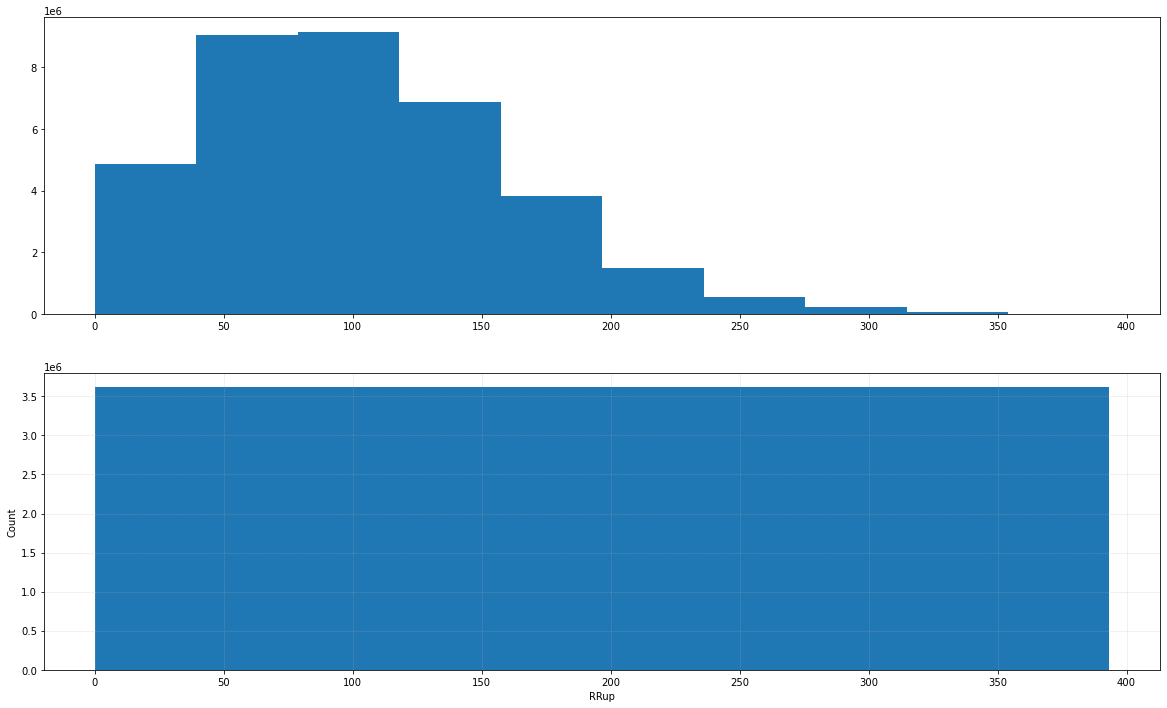

In [21]:
fig = plt.figure(figsize=(20, 12))

ax_1 = fig.add_subplot(2, 1, 1)
ax_1.hist(sample_df.rrup.values)

ax_3 = fig.add_subplot(2, 1, 2, sharex=ax_1)
ax_3.hist(sample_df.rrup.values, weights=sample_weights)

ax_3.set_xlabel(f"RRup")
ax_3.set_ylabel(f"Count")
ax_3.grid(linewidth=0.5, alpha=0.5, linestyle="--")

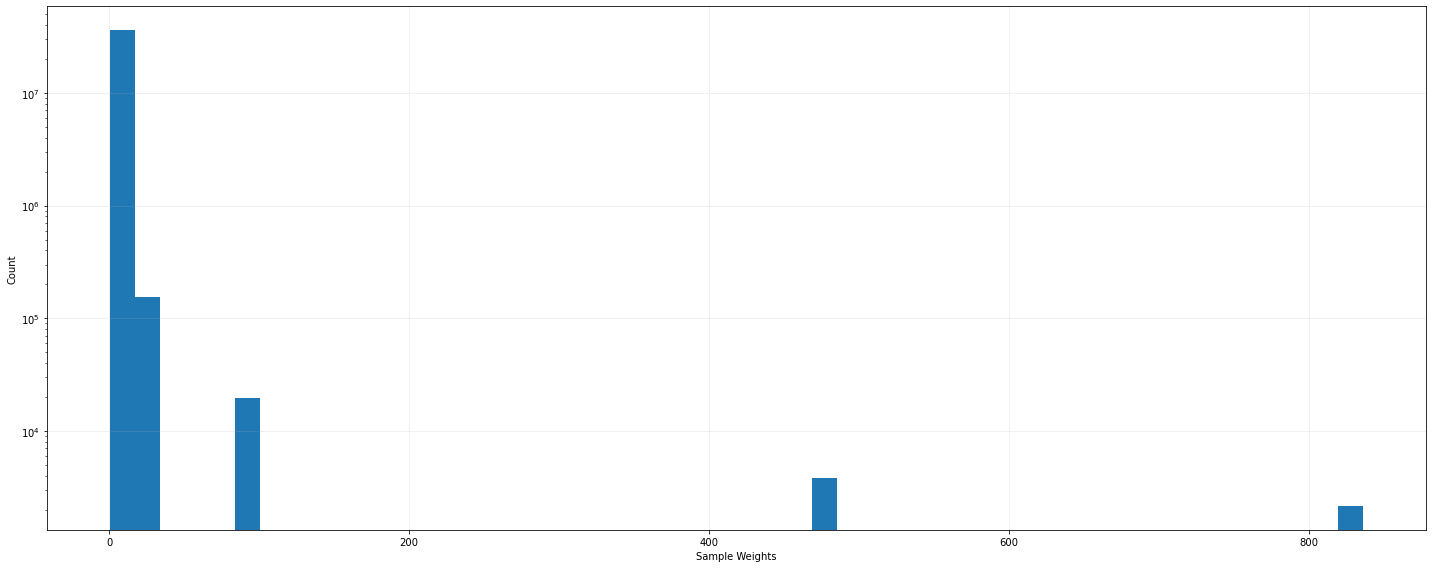

In [35]:
# Distribution of sample weights
fig = plt.figure(figsize=(20, 8))

plt.hist(sample_weights, bins=50, log=True)

plt.xlabel(f"Sample Weights")
plt.ylabel(f"Count")
plt.grid(linewidth=0.5, alpha=0.5, linestyle="--")
plt.tight_layout()

Clearly some extreme weights, reduce these

In [ ]:
print(sample_weights.min(), sample_weights.max())

In [39]:
# Extreme large weights are probably not great either as
# this leads to single data points having way to much effect
# Therefore limit the maximum weight
sample_weights[sample_weights > 15] = 15.0

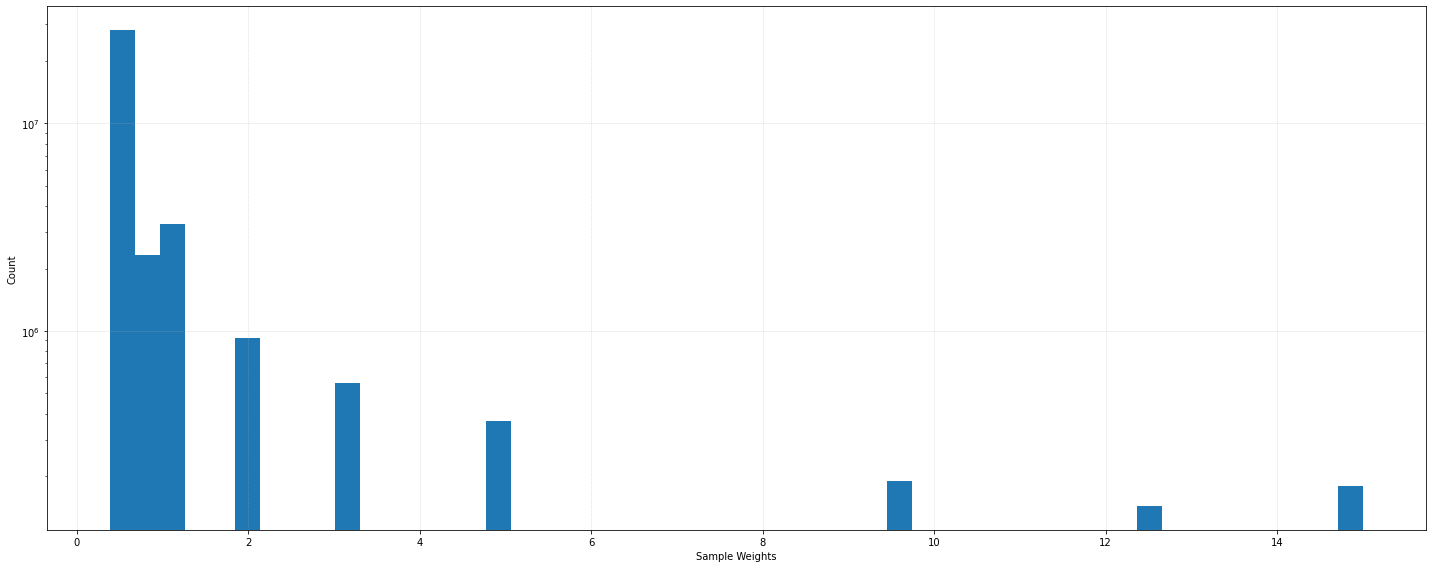

In [40]:
# Truncated distribution of sample weights
fig = plt.figure(figsize=(20, 8))

plt.hist(sample_weights, bins=50, log=True)

plt.xlabel(f"Sample Weights")
plt.ylabel(f"Count")
plt.grid(linewidth=0.5, alpha=0.5, linestyle="--")
plt.tight_layout()

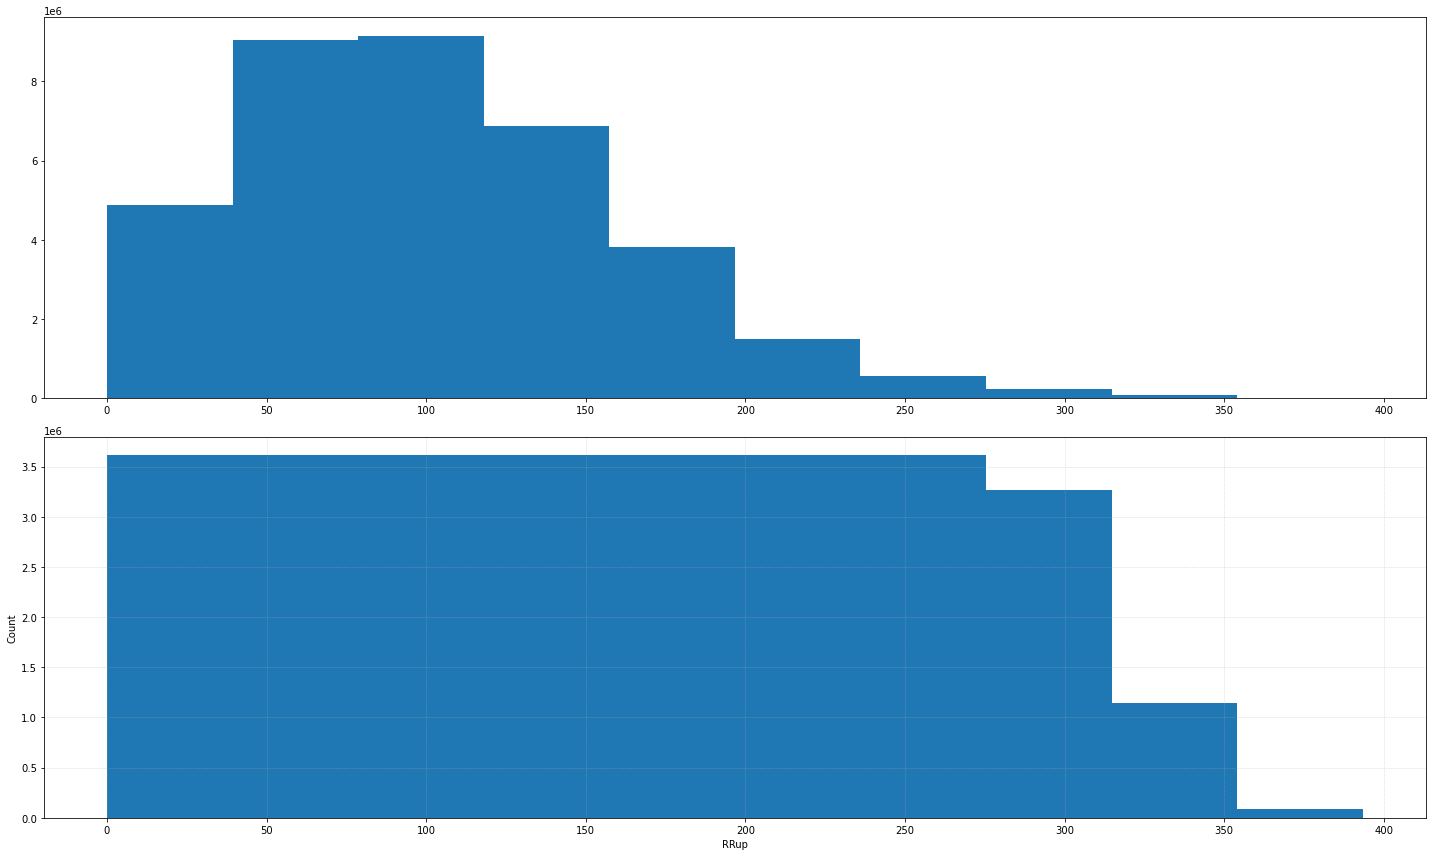

In [42]:
fig = plt.figure(figsize=(20, 12))

ax_1 = fig.add_subplot(2, 1, 1)
ax_1.hist(sample_df.rrup.values)

ax_3 = fig.add_subplot(2, 1, 2, sharex=ax_1)
ax_3.hist(sample_df.rrup.values, weights=sample_weights)

ax_3.set_xlabel(f"RRup")
ax_3.set_ylabel(f"Count")
ax_3.grid(linewidth=0.5, alpha=0.5, linestyle="--")

fig.tight_layout()